# Tabelle der t-Verteilung – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/tabelle-t-verteilung)

Die **t-Verteilung** (Student-Verteilung) wird beim t-Test verwendet.
Sie hängt von den **Freiheitsgraden (df)** ab und nähert sich mit wachsendem df
der Standardnormalverteilung an.

**Vergleich berechneter t-Wert mit kritischem t-Wert:**
$$|t_{berechnet}| > t_{krit}(df, \alpha) \Rightarrow H_0 \text{ verwerfen}$$

**Freiheitsgrade:**

| t-Test | df |
|---|---|
| Einstichproben | n − 1 |
| Unabhängige Stichproben | n₁ + n₂ − 2 |
| Abhängige Stichproben | n − 1 |

**Tabelle lesen:**
- Zeile = df (Freiheitsgrade)
- Spalte = zweiseitige Fläche (1 − α) oder einseitig (1 − α/2)
- **Gerichtete Hypothese (einseitig):** Spalte 1 − α ablesen
- **Ungerichtete Hypothese (zweiseitig):** Spalte 1 − α/2 ablesen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. t-Verteilung vs. Standardnormalverteilung

Mit zunehmenden Freiheitsgraden nähert sich die t-Verteilung der z-Verteilung an.
Bei df → ∞ sind sie identisch.

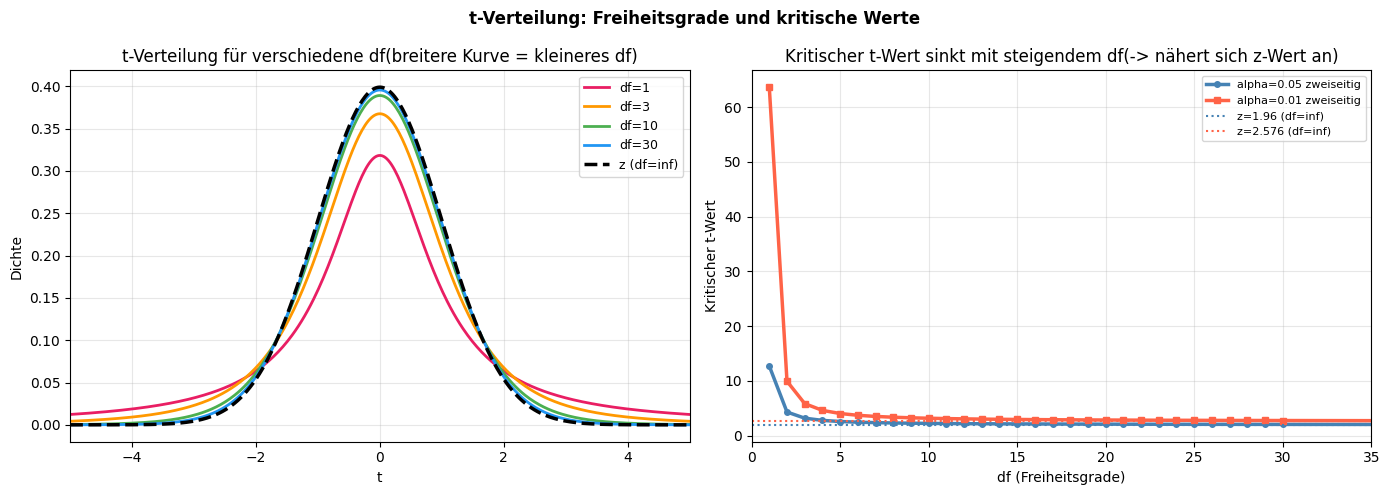

In [2]:
x = np.linspace(-5, 5, 400)
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("t-Verteilung: Freiheitsgrade und kritische Werte", fontsize=12,
             fontweight="bold")

farben = ["#E91E63", "#FF9800", "#4CAF50", "#2196F3", "black"]
df_liste = [1, 3, 10, 30]
for df_v, fc in zip(df_liste, farben):
    axes[0].plot(x, t_dist.pdf(x, df_v), color=fc, linewidth=2,
                 label="df=" + str(df_v))
axes[0].plot(x, norm.pdf(x), color="black", linewidth=2.5,
             linestyle="--", label="z (df=inf)")
axes[0].set_title("t-Verteilung für verschiedene df(breitere Kurve = kleineres df)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-5, 5)

# Kritische t-Werte für alpha=0.05 zweiseitig je df
df_krit = list(range(1, 31)) + [40, 60, 80, 100, 1000]
t_krit_05 = [round(t_dist.ppf(0.975, df_v), 4) for df_v in df_krit]
t_krit_01 = [round(t_dist.ppf(0.995, df_v), 4) for df_v in df_krit]

axes[1].plot(df_krit[:35], t_krit_05[:35], "o-", color="steelblue",
             linewidth=2.5, markersize=4, label="alpha=0.05 zweiseitig")
axes[1].plot(df_krit[:35], t_krit_01[:35], "s-", color="tomato",
             linewidth=2.5, markersize=4, label="alpha=0.01 zweiseitig")
axes[1].axhline(1.96, color="steelblue", linestyle=":", linewidth=1.5,
                label="z=1.96 (df=inf)")
axes[1].axhline(2.576, color="tomato", linestyle=":", linewidth=1.5,
                label="z=2.576 (df=inf)")
axes[1].set_title("Kritischer t-Wert sinkt mit steigendem df(-> nähert sich z-Wert an)")
axes[1].set_xlabel("df (Freiheitsgrade)")
axes[1].set_ylabel("Kritischer t-Wert")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 35)

plt.tight_layout()
plt.show()

## 2. t-Tabelle (numiqo)

**Kritische t-Werte** für zweiseitige Flächen – exakt wie auf numiqo.de.
Zeilen = df, Spalten = zweiseitige Fläche (1 − α).

In [3]:
# t-Tabelle exakt wie numiqo
df_zeilen = list(range(1, 31)) + [40, 60, 80, 100, 1000]
flaechen  = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99, 0.998, 0.999]
# Entsprechende alpha-Werte: 1 - Fläche
# ppf((1 + Fläche) / 2, df) für zweiseitig

tabelle = {}
for df_v in df_zeilen:
    row = {}
    for f in flaechen:
        t_krit_v = round(t_dist.ppf((1 + f) / 2, df_v), 3)
        row[str(f)] = t_krit_v
    tabelle[str(df_v)] = row

df_tab = pd.DataFrame(tabelle).T
df_tab.index.name = "df"
df_tab.columns = [str(f) for f in flaechen]

print("t-Tabelle (kritische t-Werte, zweiseitig)")
print("Spalten: zweiseitige Fläche (1-alpha)")
print()
print(df_tab.to_string())
print()
print("Lesebeispiel:")
print("df=10, alpha=0.05 zweiseitig -> t_krit=" +
      str(round(t_dist.ppf(0.975, 10), 3)) + "  (numiqo: 2.228)")
print("df=20, alpha=0.05 zweiseitig -> t_krit=" +
      str(round(t_dist.ppf(0.975, 20), 3)) + "  (numiqo: 2.086)")

t-Tabelle (kritische t-Werte, zweiseitig)
Spalten: zweiseitige Fläche (1-alpha)

        0.5    0.6    0.7    0.8    0.9    0.95    0.98    0.99    0.998    0.999
df                                                                               
1     1.000  1.376  1.963  3.078  6.314  12.706  31.821  63.657  318.309  636.619
2     0.816  1.061  1.386  1.886  2.920   4.303   6.965   9.925   22.327   31.599
3     0.765  0.978  1.250  1.638  2.353   3.182   4.541   5.841   10.215   12.924
4     0.741  0.941  1.190  1.533  2.132   2.776   3.747   4.604    7.173    8.610
5     0.727  0.920  1.156  1.476  2.015   2.571   3.365   4.032    5.893    6.869
6     0.718  0.906  1.134  1.440  1.943   2.447   3.143   3.707    5.208    5.959
7     0.711  0.896  1.119  1.415  1.895   2.365   2.998   3.499    4.785    5.408
8     0.706  0.889  1.108  1.397  1.860   2.306   2.896   3.355    4.501    5.041
9     0.703  0.883  1.100  1.383  1.833   2.262   2.821   3.250    4.297    4.781
10    0.700  0.87

## 3. p-Wert aus t-Wert berechnen

`scipy.stats.t.sf(|t|, df)` gibt die rechtsseitige Wahrscheinlichkeit zurück.
Für zweiseitig: `2 * t.sf(|t|, df)`.

In [7]:
def p_aus_t(t_val, df_v, test="zweiseitig"):
    if test == "linksseitig":
        return t_dist.cdf(t_val, df_v)
    elif test == "rechtsseitig":
        return t_dist.sf(t_val, df_v)
    else:
        return 2 * t_dist.sf(abs(t_val), df_v)

def t_krit(df_v, alpha=0.05, test="zweiseitig"):
    if test == "zweiseitig":
        return round(t_dist.ppf(1 - alpha/2, df_v), 4)
    else:
        return round(t_dist.ppf(1 - alpha, df_v), 4)

print("p-Wert aus t-Wert")
print()
print("t-Wert  df    p (zweiseitig)  signifikant?")
print()
for t_v, df_v in [(2.0,10), (2.228,10), (2.5,10), (3.0,10),
                   (2.0,30), (1.96,1000)]:
    p = p_aus_t(t_v, df_v)
    sig = "JA" if p < 0.05 else "nein"
    print(str(round(t_v,3)).rjust(6) + "  " + str(df_v).rjust(4) +
          "   " + str(round(p,4)).ljust(14) + "  " + sig)

print()
print("Kritische t-Werte")
print()
print("df     alpha=0.10  alpha=0.05  alpha=0.01  alpha=0.001")
print()
for df_v in [1, 5, 10, 20, 30, 60, 100, 1000]:
    t10 = t_krit(df_v, 0.10)
    t05 = t_krit(df_v, 0.05)
    t01 = t_krit(df_v, 0.01)
    t001 = t_krit(df_v, 0.001)
    print(str(df_v).rjust(4) + "   " +
          str(t10).rjust(10) + "  " + str(t05).rjust(10) +
          "  " + str(t01).rjust(10) + "  " + str(t001).rjust(11))

p-Wert aus t-Wert

t-Wert  df    p (zweiseitig)  signifikant?

   2.0    10   0.0734          nein
 2.228    10   0.05            nein
   2.5    10   0.0314          JA
   3.0    10   0.0133          JA
   2.0    30   0.0546          nein
  1.96  1000   0.0503          nein

Kritische t-Werte

df     alpha=0.10  alpha=0.05  alpha=0.01  alpha=0.001

   1       6.3138     12.7062     63.6567     636.6192
   5        2.015      2.5706      4.0321       6.8688
  10       1.8125      2.2281      3.1693       4.5869
  20       1.7247       2.086      2.8453       3.8495
  30       1.6973      2.0423        2.75        3.646
  60       1.6706      2.0003      2.6603       3.4602
 100       1.6602       1.984      2.6259       3.3905
1000       1.6464      1.9623      2.5808       3.3003


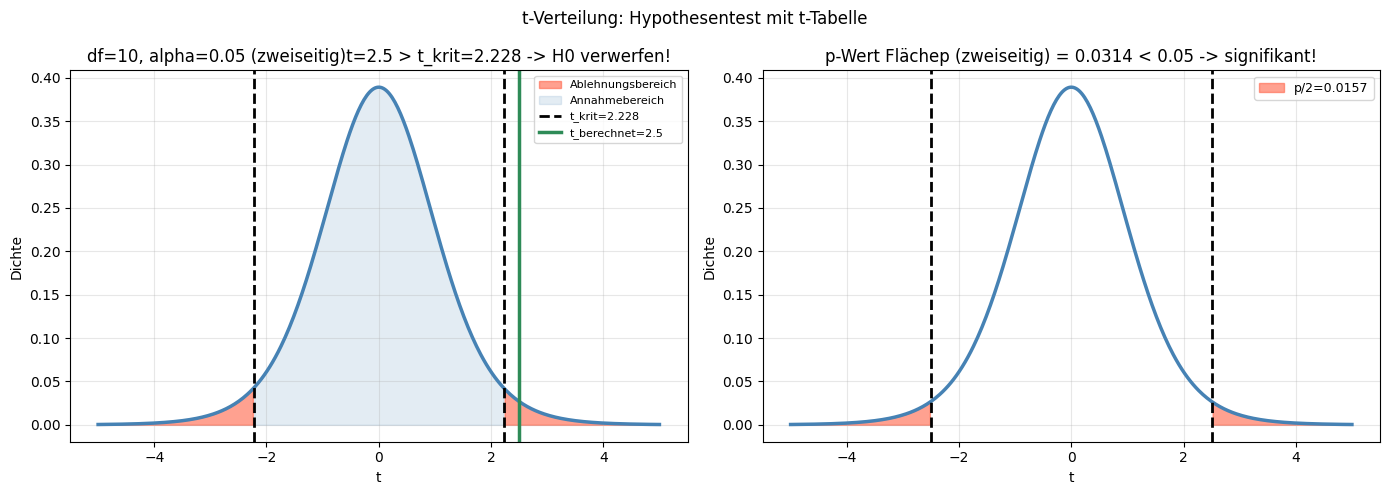

In [5]:
# Visualisierung: Kritische Bereiche für t-Verteilung
df_bsp = 10
t_val_bsp = 2.5
alpha = 0.05
t_krit_bsp = t_dist.ppf(1 - alpha/2, df_bsp)
p_bsp = 2 * t_dist.sf(abs(t_val_bsp), df_bsp)

x_t = np.linspace(-5, 5, 400)
pdf_t = t_dist.pdf(x_t, df_bsp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("t-Verteilung: Hypothesentest mit t-Tabelle", fontsize=12)

# 1. Kritische Bereiche
axes[0].plot(x_t, pdf_t, color="steelblue", linewidth=2.5)
axes[0].fill_between(x_t, pdf_t, where=(x_t >= t_krit_bsp),
                     color="tomato", alpha=0.6, label="Ablehnungsbereich")
axes[0].fill_between(x_t, pdf_t, where=(x_t <= -t_krit_bsp),
                     color="tomato", alpha=0.6)
axes[0].fill_between(x_t, pdf_t,
                     where=(x_t > -t_krit_bsp) & (x_t < t_krit_bsp),
                     color="steelblue", alpha=0.15, label="Annahmebereich")
axes[0].axvline(t_krit_bsp,  color="black", linestyle="--", linewidth=2,
                label="t_krit=" + str(round(t_krit_bsp,3)))
axes[0].axvline(-t_krit_bsp, color="black", linestyle="--", linewidth=2)
axes[0].axvline(t_val_bsp, color="seagreen", linewidth=2.5,
                label="t_berechnet=" + str(t_val_bsp))
axes[0].set_title("df=" + str(df_bsp) + ", alpha=0.05 (zweiseitig)t=" +
                  str(t_val_bsp) + " > t_krit=" + str(round(t_krit_bsp,3)) +
                  " -> H0 verwerfen!")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. p-Wert Fläche
axes[1].plot(x_t, pdf_t, color="steelblue", linewidth=2.5)
axes[1].fill_between(x_t, pdf_t, where=(x_t >= t_val_bsp),
                     color="tomato", alpha=0.6, label="p/2=" + str(round(p_bsp/2,4)))
axes[1].fill_between(x_t, pdf_t, where=(x_t <= -t_val_bsp),
                     color="tomato", alpha=0.6)
axes[1].axvline(t_val_bsp, color="black", linestyle="--", linewidth=2)
axes[1].axvline(-t_val_bsp, color="black", linestyle="--", linewidth=2)
axes[1].set_title("p-Wert Flächep (zweiseitig) = " + str(round(p_bsp,4)) +
                  " < 0.05 -> signifikant!")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Zusammenfassung

```
t-Verteilung Tabelle – Übersicht
│
├── WANN?
│   t-Test (Einstichproben, abhängig, unabhängig)
│   Vergleich berechneter t-Wert mit kritischem t-Wert
│
├── FREIHEITSGRADE (df)
│   Einstichproben:   n - 1
│   Unabhängig:      n1 + n2 - 2
│   Abhängig:        n - 1
│
├── TABELLE LESEN
│   Zeile = df
│   Spalte = zweiseitige Fläche (1 - alpha)
│   Gerichtet (einseitig):   Spalte 1-alpha
│   Ungerichtet (zweiseitig): Spalte 1-alpha/2
│
├── ENTSCHEIDUNGSREGEL
│   |t_berechnet| > t_krit -> H0 verwerfen (signifikant)
│   |t_berechnet| <= t_krit -> H0 beibehalten
│
├── WICHTIGE t_krit (alpha=0.05, zweiseitig)
│   df=10:  t_krit = 2.228
│   df=20:  t_krit = 2.086
│   df=30:  t_krit = 2.042
│   df=inf: t_krit = 1.960  (= z-Wert)
│
└── PYTHON
    from scipy.stats import t
    p_wert  = 2 * t.sf(abs(t_val), df)
    t_krit  = t.ppf(1 - alpha/2, df)  # zweiseitig
    t_krit  = t.ppf(1 - alpha, df)    # einseitig
```

---
Quelle: [numiqo.de/tutorial/tabelle-t-verteilung](https://numiqo.de/tutorial/tabelle-t-verteilung)